In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.cluster import OPTICS, cluster_optics_dbscan

In [2]:
# 1. Load dataset
df = pd.read_csv('final_dance_dataset.csv')

# 2. Select features
features = [col for col in df.columns if any(axis in col for axis in ['x', 'y', 'z']) and 'frame' not in col]
X = df[features]

# 3. Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

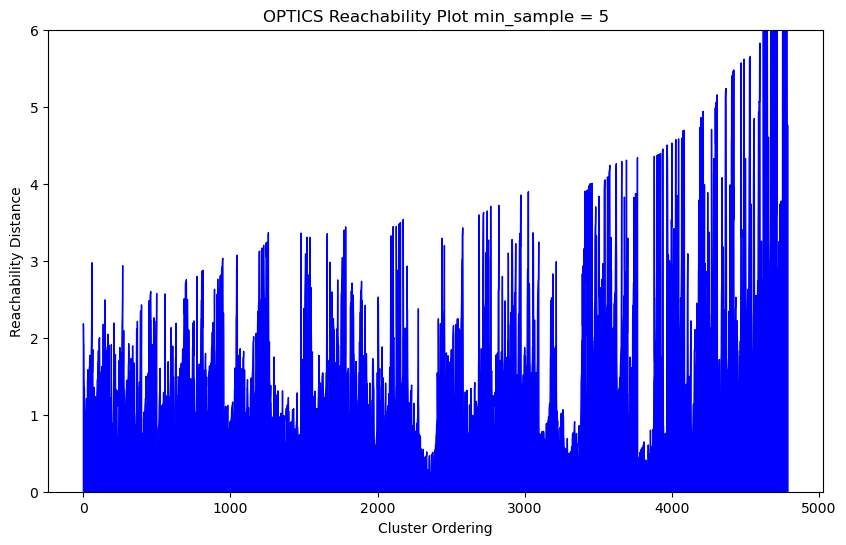

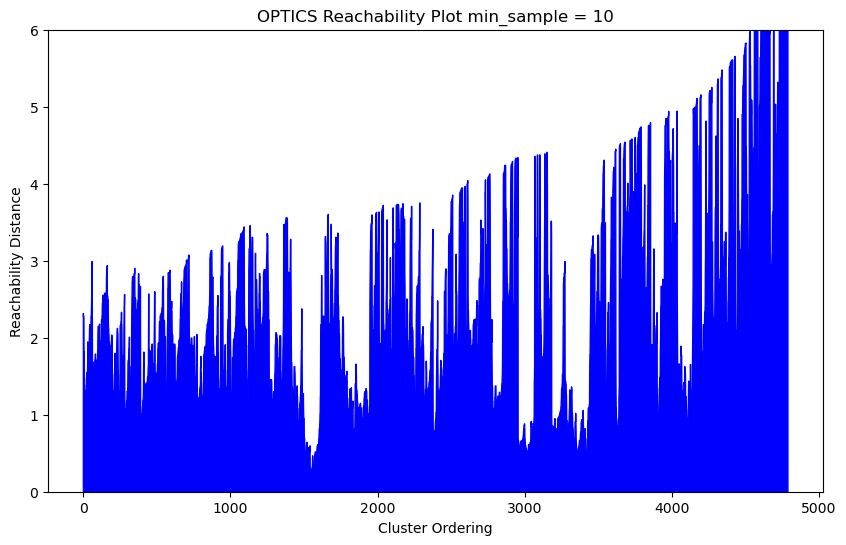

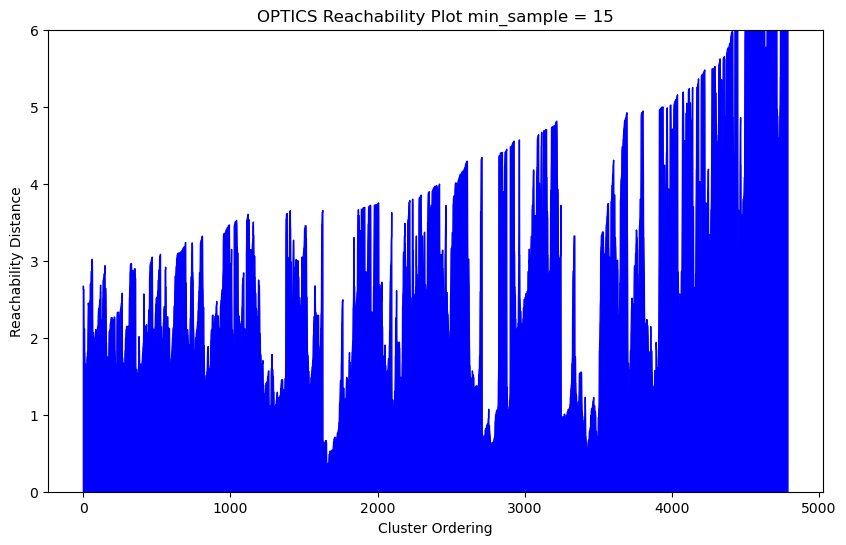

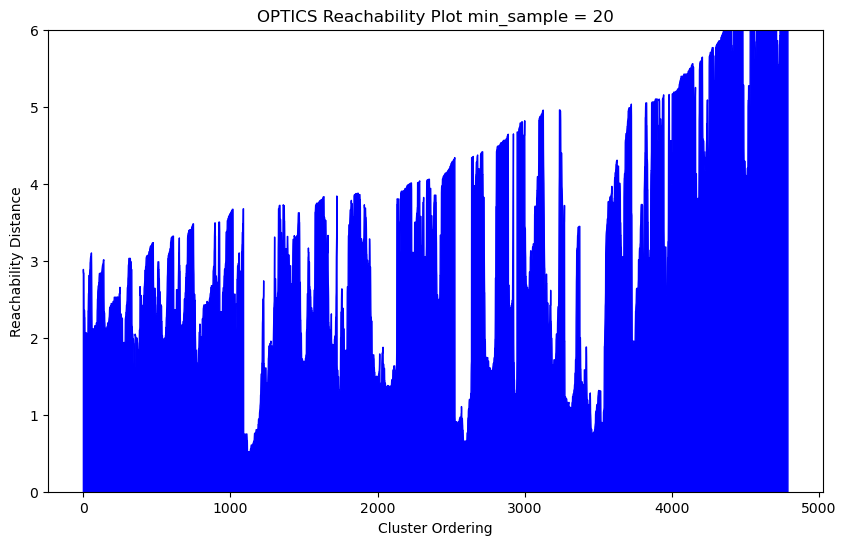

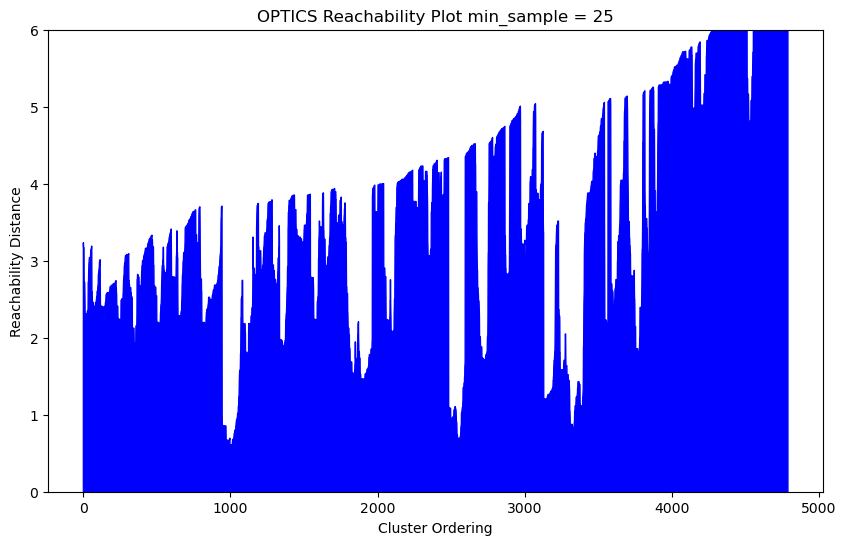

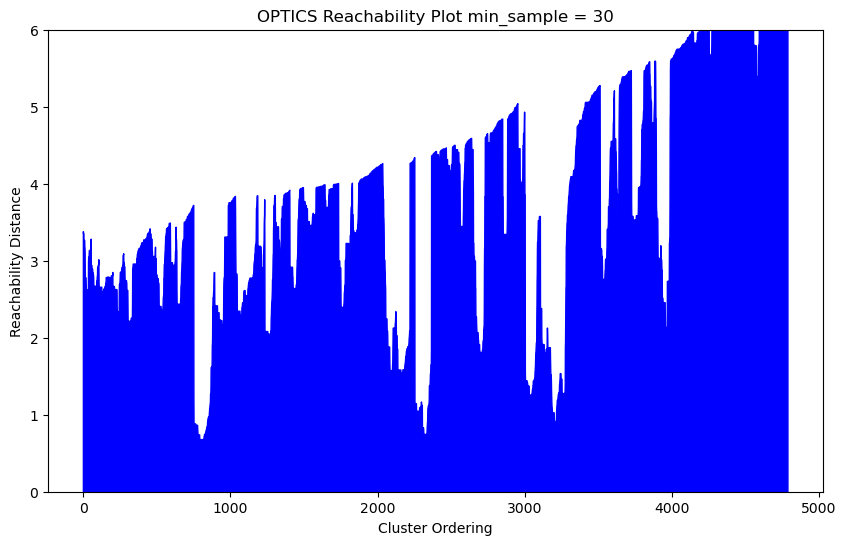

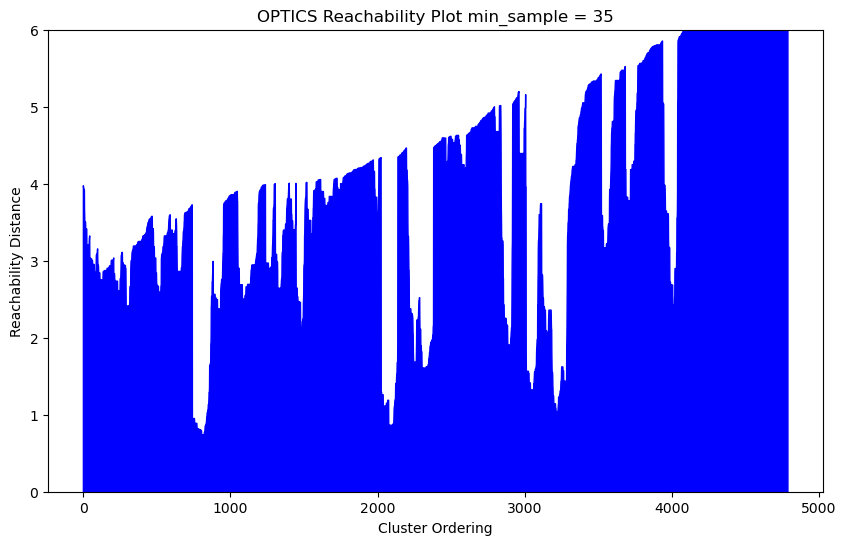

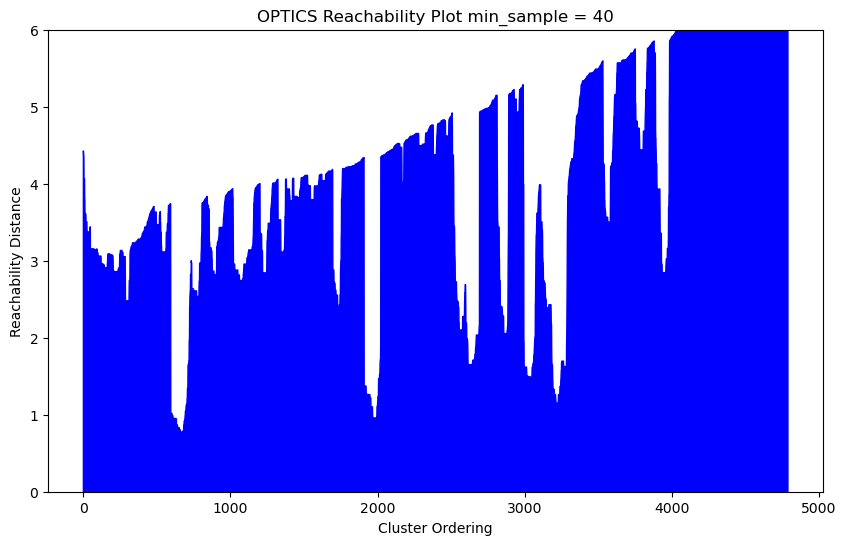

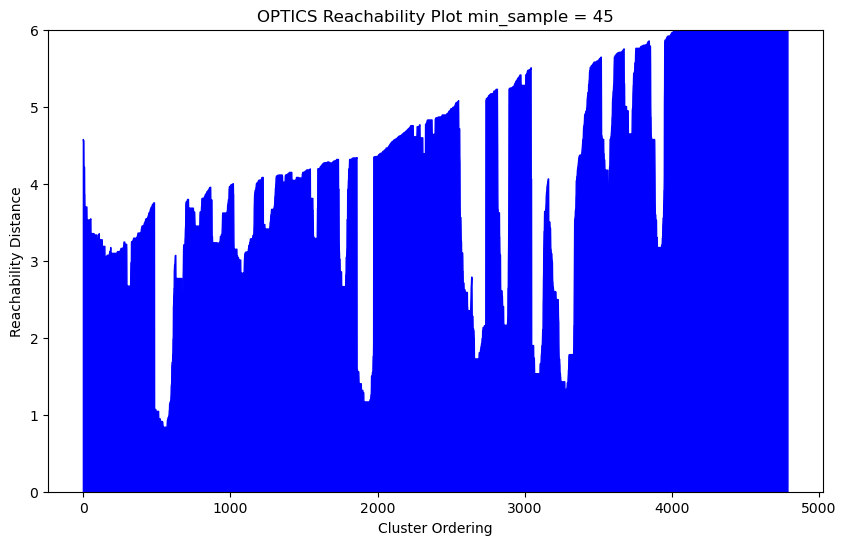

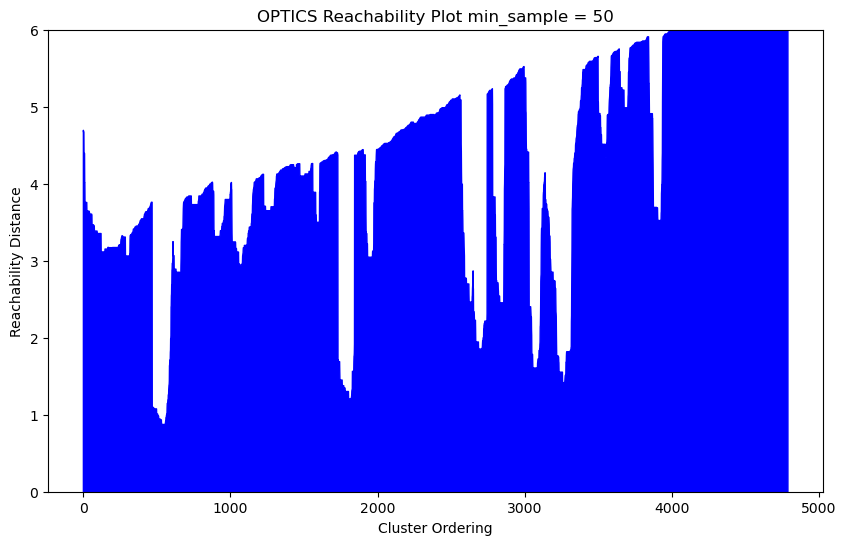

In [3]:
for ms in range(5, 55, 5):
    optics = OPTICS(min_samples=ms)
    optics.fit(X_scaled)
    plt.figure(figsize=(10,6))
    plt.title("OPTICS Reachability Plot min_sample = " + str(ms))
    plt.fill_between(df.index, optics.reachability_[optics.ordering_], color='blue')
    plt.ylabel('Reachability Distance')
    plt.xlabel('Cluster Ordering')
    plt.ylim(0,6)
    plt.show()

In [5]:
optics = OPTICS(min_samples=50)
optics.fit(X_scaled)
eps_value = 2.4
labelsa_ = cluster_optics_dbscan(
    reachability=optics.reachability_,
    core_distances=optics.core_distances_,
    ordering=optics.ordering_,
    eps=eps_value,
)
print(type(labelsa_)) 
print(labelsa_)

<class 'numpy.ndarray'>
[-1 -1 -1 ... -1 -1 -1]


In [6]:
df['cluster_id'] = labelsa_
# 10. Save
df.to_csv('DBSCAN_clusters.csv', index=False)
print("Final clustered dataset saved")

Final clustered dataset saved


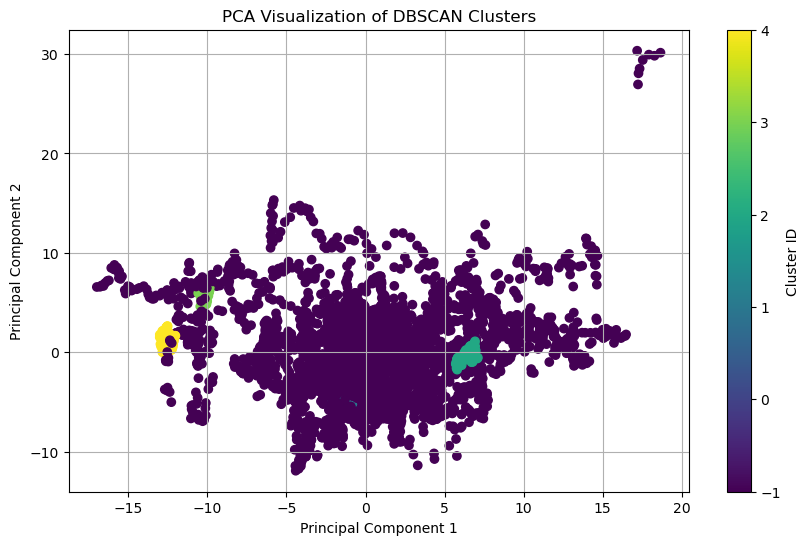

In [7]:
from sklearn.decomposition import PCA

# Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster_id'])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of DBSCAN Clusters')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True)
plt.savefig('pca_clusters_dbcan.png')
plt.show()

Running t-SNE...


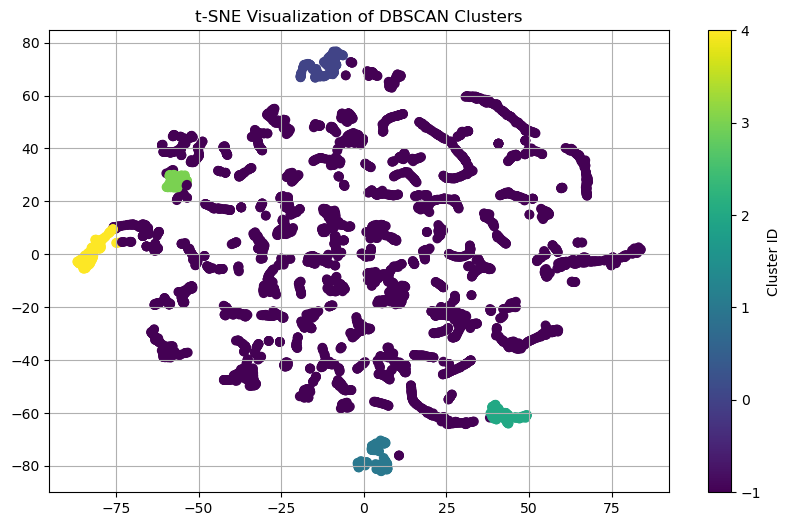

In [8]:
from sklearn.manifold import TSNE

print("Running t-SNE...")

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df['cluster_id'])
plt.title('t-SNE Visualization of DBSCAN Clusters')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True)
plt.savefig('tsne_clusters_dbscan.png')
plt.show()